# Notebook 03: DQN com Self-Play

Este notebook é dedicado ao treino, avaliação e análise do agente `DQN` do projeto.

## Objetivo

O objetivo deste notebook é:

- treinar o `DQN`;
- comparar diferentes configurações;
- analisar checkpoints guardados;
- medir evolução contra baselines e contra versões anteriores;
- observar partidas concretas do agente.

## Passo 1: Preparação do ambiente

Importamos o código do projeto, os agentes baseline, o agente `DQN`, as utilidades gráficas e a pasta `outputs/` onde os artefactos são guardados.

In [12]:
from __future__ import annotations

import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
OUTPUTS

from connect4_rl.agents.baselines import HeuristicAgent, RandomAgent
from connect4_rl.agents.learning import DQNAgent, DQNConfig
from connect4_rl.envs.connect_four import apply_action, initial_state, is_terminal, legal_actions, render_ascii
from connect4_rl.experiments import compute_elo_ratings, round_robin_detailed
from connect4_rl.experiments.dqn_training import train_dqn_self_play


## Passo 2: Configuração do treino de DQN

Nesta célula definimos o comportamento principal do notebook.

- `train_from_notebook`: se estiver a `True`, o notebook lança um novo treino de `DQN`.
- `run_ablation_from_notebook`: se estiver a `True`, o notebook testa várias configurações de `DQN`.
- `run_checkpoint_elo`: se estiver a `True`, calcula `Elo` entre checkpoints do mesmo treino.
- `training_config`: contém os hiperparâmetros principais do treino.
- `checkpoint_dir`: pasta onde ficam guardados checkpoints e métricas.

In [13]:
train_from_notebook = True
# Se True, corre uma pequena ablação de configurações de DQN.
run_ablation_from_notebook = True

training_config = DQNConfig(
    episodes=180,
    eval_interval=30,
    eval_games=12,
    gradient_updates_per_step=2,
    seed=7,
)

run_name = f"dqn_notebook_seed_{training_config.seed}"
checkpoint_dir = OUTPUTS / run_name
# Se True, calcula Elo entre vários checkpoints do mesmo treino.
run_checkpoint_elo = True

ablation_episodes = 180
ablation_seeds = [7, 17, 27]
ablation_builders = {
    "base": lambda seed: DQNConfig(
        episodes=ablation_episodes,
        eval_interval=30,
        eval_games=12,
        gradient_updates_per_step=2,
        seed=seed,
    ),
    "more_updates": lambda seed: DQNConfig(
        episodes=ablation_episodes,
        eval_interval=30,
        eval_games=12,
        gradient_updates_per_step=3,
        seed=seed,
    ),
    "no_symmetry": lambda seed: DQNConfig(
        episodes=ablation_episodes,
        eval_interval=30,
        eval_games=12,
        gradient_updates_per_step=3,
        use_horizontal_symmetry_augmentation=False,
        seed=seed,
    ),
}

training_config, checkpoint_dir


(DQNConfig(episodes=180, gamma=0.99, learning_rate=0.0003, batch_size=64, replay_capacity=20000, min_replay_size=128, target_sync_interval=200, target_ema_tau=0.02, opponent_refresh_interval=30, opponent_pool_size=5, hidden_dim=128, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_steps=6000, warmup_episodes=40, opponent_epsilon=0.05, gradient_updates_per_step=2, random_opponent_fraction=0.2, heuristic_opponent_fraction=0.2, eval_interval=30, eval_games=12, seed=7, device='cpu', checkpoint_score_heuristic_weight=2.0, use_horizontal_symmetry_augmentation=True),
 PosixPath('/home/vasco44/AR/outputs/dqn_notebook_seed_7'))

## Passo 3: Treino principal do DQN

Se o treino estiver ativado, esta célula lança uma corrida de `DQN` em self-play e mostra um resumo inicial dos resultados.

In [14]:
# `None` significa que ainda não existe um treino lançado nesta sessão do notebook.
trained_agent = None
trained_metrics = None

if train_from_notebook:
    trained_agent, trained_metrics = train_dqn_self_play(training_config, checkpoint_dir=checkpoint_dir)
    print({
        "episodes": len(trained_metrics.episode_rewards),
        "best_score": trained_metrics.best_score,
        "last_eval": trained_metrics.evaluation[-1] if trained_metrics.evaluation else {},
        "best_checkpoint_path": trained_metrics.best_checkpoint_path,
    })
else:
    print("Notebook training skipped.")


{'episodes': 180, 'best_score': 1.0, 'last_eval': {'episode': 180.0, 'vs_random_win_rate': 1.0, 'vs_heuristic_win_rate': 0.0, 'vs_previous_win_rate': 1.0}, 'best_checkpoint_path': '/home/vasco44/AR/outputs/dqn_notebook_seed_7/dqn_best.pt'}


## Passo 4: Ablação opcional do DQN

Esta célula permite comparar várias famílias de configuração do `DQN` sem sair do notebook. É útil quando queremos escolher uma configuração oficial.

In [15]:
# Dicionário onde serão guardados os resultados da ablação, se ela for executada.
ablation_summary = {}

if run_ablation_from_notebook:
    for name, builder in ablation_builders.items():
        runs = []
        for seed in ablation_seeds:
            config = builder(seed)
            _, metrics = train_dqn_self_play(config, checkpoint_dir=OUTPUTS / f"dqn_ablation_{name}_seed_{seed}")
            last_eval = metrics.evaluation[-1] if metrics.evaluation else {}
            runs.append({
                "seed": seed,
                "best_score": metrics.best_score,
                "last_vs_random": float(last_eval.get("vs_random_win_rate", 0.0)),
                "last_vs_heuristic": float(last_eval.get("vs_heuristic_win_rate", 0.0)),
                "loss_points": len(metrics.losses),
                "mean_reward_last_20": statistics.fmean(metrics.episode_rewards[-20:]) if metrics.episode_rewards else 0.0,
            })

        ablation_summary[name] = {
            "runs": runs,
            "mean_best_score": statistics.fmean(run["best_score"] for run in runs),
            "mean_last_vs_random": statistics.fmean(run["last_vs_random"] for run in runs),
            "mean_last_vs_heuristic": statistics.fmean(run["last_vs_heuristic"] for run in runs),
            "mean_reward_last_20": statistics.fmean(run["mean_reward_last_20"] for run in runs),
        }

    print(json.dumps(ablation_summary, indent=2))
else:
    print("Notebook ablation skipped. Use saved runs below for analysis.")


{
  "base": {
    "runs": [
      {
        "seed": 7,
        "best_score": 1.0,
        "last_vs_random": 1.0,
        "last_vs_heuristic": 0.0,
        "loss_points": 3074,
        "mean_reward_last_20": 0.0
      },
      {
        "seed": 17,
        "best_score": 1.0,
        "last_vs_random": 0.0,
        "last_vs_heuristic": 0.0,
        "loss_points": 2722,
        "mean_reward_last_20": -0.2
      },
      {
        "seed": 27,
        "best_score": 1.0,
        "last_vs_random": 1.0,
        "last_vs_heuristic": 0.0,
        "loss_points": 2675,
        "mean_reward_last_20": -0.5
      }
    ],
    "mean_best_score": 1.0,
    "mean_last_vs_random": 0.6666666666666666,
    "mean_last_vs_heuristic": 0.0,
    "mean_reward_last_20": -0.2333333333333333
  },
  "more_updates": {
    "runs": [
      {
        "seed": 7,
        "best_score": 1.0,
        "last_vs_random": 0.0,
        "last_vs_heuristic": 0.0,
        "loss_points": 4298,
        "mean_reward_last_20": -0.2
      

## Passo 5: Carregamento das corridas guardadas

Aqui recolhemos todos os ficheiros `metrics_final.json` associados ao `DQN`, para analisar resultados passados sem treinar de novo.

In [16]:
def load_metrics_files(root: Path) -> list[dict]:
    runs = []
    for metrics_path in sorted(root.glob("**/metrics_final.json")):
        if "dqn" not in metrics_path.parent.name:
            continue
        data = json.loads(metrics_path.read_text(encoding="utf-8"))
        run_name = metrics_path.parent.name
        family = run_name.split("_seed_")[0] if "_seed_" in run_name else run_name
        runs.append({
            "run_name": run_name,
            "family": family,
            "path": metrics_path,
            "data": data,
        })
    return runs

all_runs = load_metrics_files(OUTPUTS)
[(run["run_name"], len(run["data"].get("evaluation", []))) for run in all_runs]


[('dqn_ablation_base_seed_17', 6),
 ('dqn_ablation_base_seed_27', 6),
 ('dqn_ablation_base_seed_7', 6),
 ('dqn_ablation_more_updates_seed_17', 6),
 ('dqn_ablation_more_updates_seed_27', 6),
 ('dqn_ablation_more_updates_seed_7', 6),
 ('dqn_ablation_no_symmetry_seed_17', 6),
 ('dqn_ablation_no_symmetry_seed_27', 6),
 ('dqn_ablation_no_symmetry_seed_7', 6),
 ('dqn_notebook_seed_7', 6)]

## Passo 6: Agregação e ranking das corridas

Nesta célula construímos um resumo por família de configuração e ordenamos os resultados por desempenho.

In [17]:
def summarize_runs(runs: list[dict]) -> dict[str, dict]:
    grouped: dict[str, list[dict]] = {}
    for run in runs:
        grouped.setdefault(run["family"], []).append(run)

    summary = {}
    for family, family_runs in grouped.items():
        best_scores = [run["data"].get("best_score", float("-inf")) for run in family_runs]
        last_random = []
        last_heuristic = []
        last_previous = []
        last_reward = []
        for run in family_runs:
            evaluations = run["data"].get("evaluation", [])
            if evaluations:
                last_random.append(float(evaluations[-1].get("vs_random_win_rate", 0.0)))
                last_heuristic.append(float(evaluations[-1].get("vs_heuristic_win_rate", 0.0)))
                last_previous.append(float(evaluations[-1].get("vs_previous_win_rate", 0.0)))
            rewards = run["data"].get("episode_rewards", [])
            if rewards:
                last_reward.append(statistics.fmean(rewards[-20:]))

        summary[family] = {
            "num_runs": len(family_runs),
            "mean_best_score": statistics.fmean(best_scores) if best_scores else float("-inf"),
            "mean_last_vs_random": statistics.fmean(last_random) if last_random else 0.0,
            "mean_last_vs_heuristic": statistics.fmean(last_heuristic) if last_heuristic else 0.0,
            "mean_last_vs_previous": statistics.fmean(last_previous) if last_previous else 0.0,
            "mean_reward_last_20": statistics.fmean(last_reward) if last_reward else 0.0,
        }
    return summary

summary = summarize_runs(all_runs)
ranking = sorted(
    summary.items(),
    key=lambda item: (
        item[1]["mean_last_vs_heuristic"],
        item[1]["mean_best_score"],
        item[1]["mean_last_vs_random"],
    ),
    reverse=True,
)
ranking


[('dqn_notebook',
  {'num_runs': 1,
   'mean_best_score': 1.0,
   'mean_last_vs_random': 1.0,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 1.0,
   'mean_reward_last_20': 0.0}),
 ('dqn_ablation_base',
  {'num_runs': 3,
   'mean_best_score': 1.0,
   'mean_last_vs_random': 0.6666666666666666,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 0.6666666666666666,
   'mean_reward_last_20': -0.2333333333333333}),
 ('dqn_ablation_no_symmetry',
  {'num_runs': 3,
   'mean_best_score': 0.8333333333333334,
   'mean_last_vs_random': 0.6666666666666666,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 0.3333333333333333,
   'mean_reward_last_20': -0.23333333333333336}),
 ('dqn_ablation_more_updates',
  {'num_runs': 3,
   'mean_best_score': 0.8333333333333334,
   'mean_last_vs_random': 0.16666666666666666,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 0.6666666666666666,
   'mean_reward_last_20': -0.16666666666666666})]

## Passo 7: Gráficos agregados do DQN

Aqui desenhamos gráficos das métricas principais, incluindo desempenho contra `random`, `heuristic` e contra a versão anterior do agente.

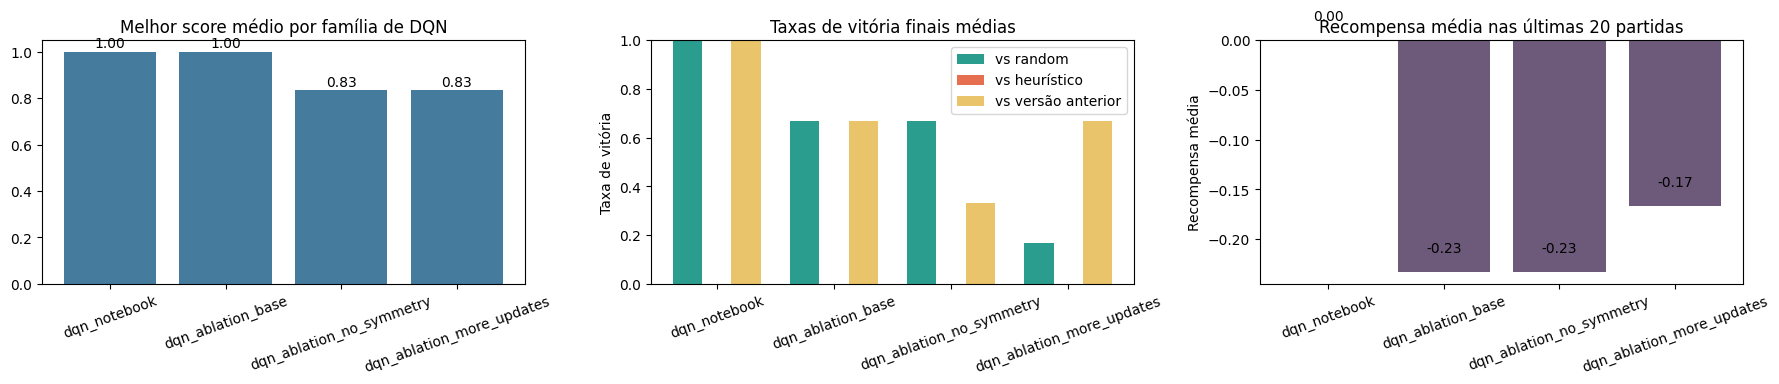

In [18]:
if ranking if "ranking" in globals() else summary:
    families = [name for name, _stats in ranking] if "ranking" in globals() and ranking else list(summary.keys())
    mean_best = [summary[name]["mean_best_score"] for name in families]
    mean_random = [summary[name]["mean_last_vs_random"] for name in families]
    mean_heur = [summary[name]["mean_last_vs_heuristic"] for name in families]
    mean_previous = [summary[name]["mean_last_vs_previous"] for name in families]
    mean_reward = [summary[name]["mean_reward_last_20"] for name in families]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].bar(families, mean_best, color="#457b9d")
    axes[0].set_title("Melhor score médio por família de DQN")
    axes[0].tick_params(axis="x", rotation=20)
    for idx, value in enumerate(mean_best):
        axes[0].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    x = list(range(len(families)))
    width = 0.25
    axes[1].bar([value - width for value in x], mean_random, width=width, label="vs random", color="#2a9d8f")
    axes[1].bar(x, mean_heur, width=width, label="vs heurístico", color="#e76f51")
    axes[1].bar([value + width for value in x], mean_previous, width=width, label="vs versão anterior", color="#e9c46a")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(families, rotation=20)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title("Taxas de vitória finais médias")
    axes[1].set_ylabel("Taxa de vitória")
    axes[1].legend()

    axes[2].bar(families, mean_reward, color="#6d597a")
    axes[2].set_title("Recompensa média nas últimas 20 partidas")
    axes[2].tick_params(axis="x", rotation=20)
    axes[2].set_ylabel("Recompensa média")
    for idx, value in enumerate(mean_reward):
        axes[2].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    fig.tight_layout()
    plt.show()


## Passo 8: Escolha do melhor checkpoint

Nesta célula identificamos e carregamos o checkpoint que representa a melhor versão guardada do `DQN`.

In [19]:
def pick_best_run(runs: list[dict]) -> dict:
    def sort_key(run: dict):
        evaluations = run["data"].get("evaluation", [])
        last = evaluations[-1] if evaluations else {}
        return (
            float(last.get("vs_heuristic_win_rate", 0.0)),
            run["data"].get("best_score", float("-inf")),
            float(last.get("vs_random_win_rate", 0.0)),
        )

    return max(runs, key=sort_key)

# `None` significa que ainda não foi carregado nenhum checkpoint vencedor.
dqn_agent = None
if all_runs:
    best_run = pick_best_run(all_runs)
    checkpoint_path = ROOT / best_run["data"]["best_checkpoint_path"]
    config = best_run["data"].get("config", {})
    dqn_agent = DQNAgent.from_checkpoint(
        checkpoint_path,
        device="cpu",
        epsilon=0.0,
        seed=int(config.get("seed", 0)),
        hidden_dim=int(config.get("hidden_dim", 128)),
    )
    print({
        "best_run": best_run["run_name"],
        "checkpoint": str(checkpoint_path),
    })
else:
    print("No DQN runs found under outputs/.")


{'best_run': 'dqn_ablation_base_seed_27', 'checkpoint': '/home/vasco44/AR/outputs/dqn_ablation_base_seed_27/dqn_best.pt'}


### Curvas detalhadas do melhor treino

Esta secção mostra a evolução temporal do melhor treino encontrado. Os gráficos foram separados por objetivo para ser mais fácil perceber se o agente está realmente a melhorar ao longo do treino.

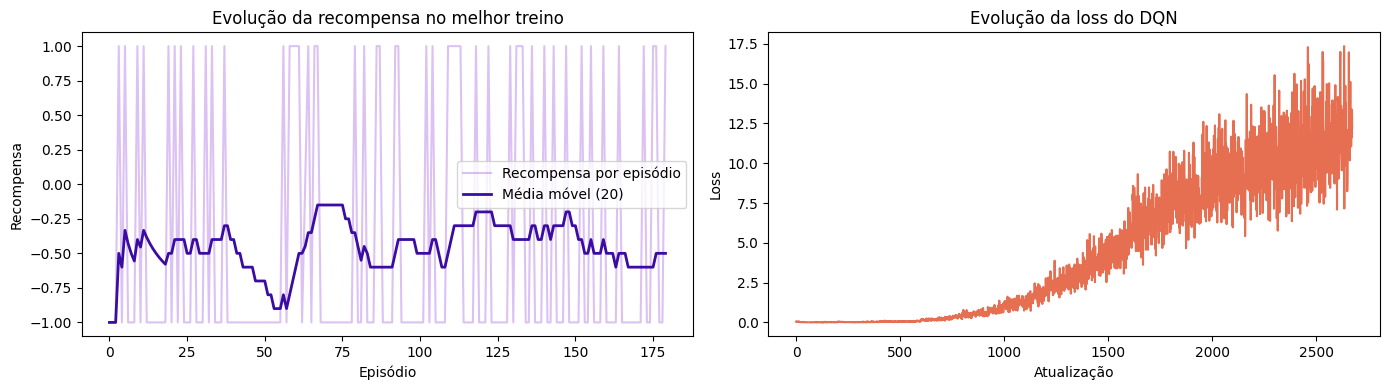

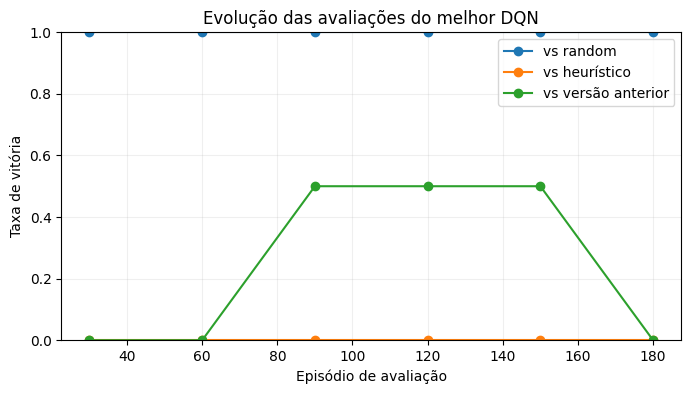

In [20]:
def rolling_mean(values: list[float], window: int = 20) -> list[float]:
    if not values:
        return []
    return [statistics.fmean(values[max(0, idx - window + 1): idx + 1]) for idx in range(len(values))]

if all_runs:
    rewards = [float(value) for value in best_run["data"].get("episode_rewards", [])]
    losses = [float(value) for value in best_run["data"].get("losses", [])]
    evaluations = best_run["data"].get("evaluation", [])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    if rewards:
        axes[0].plot(rewards, color="#9d4edd", alpha=0.35, label="Recompensa por episódio")
        axes[0].plot(rolling_mean(rewards, window=20), color="#3a0ca3", linewidth=2, label="Média móvel (20)")
        axes[0].set_title("Evolução da recompensa no melhor treino")
        axes[0].set_xlabel("Episódio")
        axes[0].set_ylabel("Recompensa")
        axes[0].legend()
    else:
        axes[0].set_title("Sem recompensas registadas")
        axes[0].axis("off")

    if losses:
        axes[1].plot(losses, color="#e76f51")
        axes[1].set_title("Evolução da loss do DQN")
        axes[1].set_xlabel("Atualização")
        axes[1].set_ylabel("Loss")
    else:
        axes[1].set_title("Sem losses registadas")
        axes[1].axis("off")

    fig.tight_layout()
    plt.show()

    if evaluations:
        eval_episodes = [int(item.get("episode", 0)) for item in evaluations]
        vs_random = [float(item.get("vs_random_win_rate", 0.0)) for item in evaluations]
        vs_heuristic = [float(item.get("vs_heuristic_win_rate", 0.0)) for item in evaluations]
        vs_previous = [float(item.get("vs_previous_win_rate", 0.0)) for item in evaluations]

        plt.figure(figsize=(8, 4))
        plt.plot(eval_episodes, vs_random, marker="o", label="vs random")
        plt.plot(eval_episodes, vs_heuristic, marker="o", label="vs heurístico")
        plt.plot(eval_episodes, vs_previous, marker="o", label="vs versão anterior")
        plt.ylim(0.0, 1.0)
        plt.title("Evolução das avaliações do melhor DQN")
        plt.xlabel("Episódio de avaliação")
        plt.ylabel("Taxa de vitória")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()


## Passo 9: Torneio entre checkpoints e cálculo de Elo

Se a opção correspondente estiver ativa, esta célula calcula um pequeno torneio entre checkpoints intermédios do `DQN` e estima o respetivo `Elo`.

In [21]:
if dqn_agent is not None and run_checkpoint_elo:
    checkpoint_files = sorted(checkpoint_path.parent.glob("dqn_episode_*.pt"))
    step = max(len(checkpoint_files) // 4, 1)
    selected = checkpoint_files[::step][:5]
    if checkpoint_files and checkpoint_files[-1] not in selected:
        selected.append(checkpoint_files[-1])

    checkpoint_factories = {}
    for path in selected:
        label = path.stem.replace("dqn_episode_", "dqn_")
        checkpoint_factories[label] = lambda cp=path, cfg=config: DQNAgent.from_checkpoint(
            cp,
            device="cpu",
            epsilon=0.0,
            seed=int(cfg.get("seed", 0)),
            hidden_dim=int(cfg.get("hidden_dim", 128)),
        )

    checkpoint_scores, checkpoint_matches = round_robin_detailed(checkpoint_factories, games_per_pair=24)
    checkpoint_elo = compute_elo_ratings(checkpoint_matches)
    print(checkpoint_scores)
    print(checkpoint_elo)
else:
    print("Set run_checkpoint_elo = True after training to compute DQN checkpoint Elo.")


{'dqn_0030': {'wins': 48.0, 'games': 120.0, 'losses': 72.0, 'win_rate': 0.4, 'draws': 0.0, 'draw_rate': 0.0}, 'dqn_0060': {'losses': 36.0, 'games': 120.0, 'wins': 84.0, 'win_rate': 0.7, 'draws': 0.0, 'draw_rate': 0.0}, 'dqn_0090': {'wins': 84.0, 'games': 120.0, 'losses': 36.0, 'win_rate': 0.7, 'draws': 0.0, 'draw_rate': 0.0}, 'dqn_0120': {'wins': 60.0, 'games': 120.0, 'losses': 60.0, 'win_rate': 0.5, 'draws': 0.0, 'draw_rate': 0.0}, 'dqn_0150': {'losses': 60.0, 'games': 120.0, 'wins': 60.0, 'win_rate': 0.5, 'draws': 0.0, 'draw_rate': 0.0}, 'dqn_0180': {'losses': 96.0, 'games': 120.0, 'wins': 24.0, 'win_rate': 0.2, 'draws': 0.0, 'draw_rate': 0.0}}
{'dqn_0030': 1461.67, 'dqn_0120': 1363.44, 'dqn_0090': 1285.19, 'dqn_0060': 1144.4, 'dqn_0180': 995.59, 'dqn_0150': 949.71}


## Passo 10: Testes finais e visualização do DQN

Aqui avaliamos o melhor `DQN` contra os baselines e renderizamos uma partida concreta para inspeção qualitativa.

In [22]:
def evaluate_agent(agent, opponent_factory, games: int = 20) -> float:
    wins = 0
    for game_idx in range(games):
        controlled_player = 1 if game_idx % 2 == 0 else 2
        opponent = opponent_factory()
        state = initial_state()
        while not is_terminal(state):
            if state.current_player == controlled_player:
                action = agent.select_action(state, legal_actions(state))
            else:
                action = opponent.select_action(state, legal_actions(state))
            state = apply_action(state, action)
        if state.winner == controlled_player:
            wins += 1
    return wins / games


def play_and_render(agent, opponent, controlled_player: int = 1) -> str:
    state = initial_state()
    transcript = ["Initial board", render_ascii(state), ""]
    move_idx = 0
    while not is_terminal(state):
        move_idx += 1
        if state.current_player == controlled_player:
            action = agent.select_action(state, legal_actions(state))
            actor = agent.name
        else:
            action = opponent.select_action(state, legal_actions(state))
            actor = opponent.name
        state = apply_action(state, action)
        transcript.append(f"Move {move_idx}: {actor} played column {action}")
        transcript.append(render_ascii(state))
        transcript.append("")

    transcript.append(f"Winner: {state.winner}")
    return "\n".join(transcript)

if dqn_agent is not None:
    summary_eval = {
        "vs_random": evaluate_agent(dqn_agent, lambda: RandomAgent(seed=0), games=20),
        "vs_heuristic": evaluate_agent(dqn_agent, lambda: HeuristicAgent(seed=0), games=20),
    }
    print(summary_eval)
    print(play_and_render(dqn_agent, HeuristicAgent(seed=1), controlled_player=1))


{'vs_random': 0.5, 'vs_heuristic': 0.0}
Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: dqn played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 2: heuristic played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 3: dqn played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . O . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 4: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . O . . . .
. . X O . . .
0 1 2 3 4 5 6

Move 5: dqn played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . O X . . .
. . X O . . .
0 1 2 3 4 5 6

Move 6: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . X O . . .
. . O X . . .
. . X O . . .
0 1 2 3 4 5 6

Move 7: dqn played column 3
. . . . . . .
. . . . . . .
. . . X . .

## Passo 11: DQN contra DQN

Por fim, colocamos o melhor `DQN` a jogar contra uma cópia do mesmo tipo de agente para observar o comportamento em confronto homogéneo.

In [23]:
if dqn_agent is not None:
    mirror_dqn = DQNAgent.from_checkpoint(
        checkpoint_path,
        device="cpu",
        epsilon=0.0,
        seed=int(config.get("seed", 0)) + 1,
        hidden_dim=int(config.get("hidden_dim", 128)),
    )
    print(play_and_render(dqn_agent, mirror_dqn, controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: dqn played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 2: dqn played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 3: dqn played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
. . O . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 4: dqn played column 2
. . . . . . .
. . . . . . .
. . O . . . .
. . X . . . .
. . O . . . .
. . X . . . .
0 1 2 3 4 5 6

Move 5: dqn played column 3
. . . . . . .
. . . . . . .
. . O . . . .
. . X . . . .
. . O . . . .
. . X X . . .
0 1 2 3 4 5 6

Move 6: dqn played column 3
. . . . . . .
. . . . . . .
. . O . . . .
. . X . . . .
. . O O . . .
. . X X . . .
0 1 2 3 4 5 6

Move 7: dqn played column 3
. . . . . . .
. . . . . . .
. . O . . . .
. . X X . . .
. . O O . . .
. . X X . . .
0 1 2 3 4 5 6

## Fecho

Este notebook deve deixar claro como o `DQN` é treinado, como é validado e quais são os seus resultados atuais no projeto.